# Common

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Dict, Any, Callable, List
from scipy.optimize import curve_fit
import sys

np.set_printoptions(linewidth=200)

In [23]:
# --- Класс для параметров стиля ---
@dataclass
class PlotParams:
    """Контейнер для параметров стиля отрисовки."""
    linestyle:  str = "-"
    color:      str = "k"
    linewidth:  float = 1.0
    marker:     Optional[str] = None
    markersize: float = 1.0
    label:      str = ""
    capsize:    float = 3.0
    markevery:  int = 1

# --- Класс-обертка для Matplotlib ---
class Plotter:
    """Класс для инкапсуляции всей логики построения графиков."""
    def __init__(self, title: str, xlabel: str, ylabel: str, figsize: tuple = (16, 9)):
        """Инициализирует фигуру и оси, задает основные подписи."""
        self.fig, self.ax = plt.subplots(figsize=figsize)
        self.ax.set_title(title, fontsize=20, pad=30)
        self.ax.set_xlabel(xlabel, fontsize=18, labelpad=20)
        self.ax.set_ylabel(ylabel, fontsize=18, labelpad=20)

    def add_plot(self, x: np.ndarray, y: np.ndarray, params: PlotParams):
        """Отрисовывает точки."""
        self.ax.plot(
            x, y,
            linestyle   = params.linestyle,
            color       = params.color,
            linewidth   = params.linewidth,
            label       = params.label,
            marker      = params.marker,
            markersize  = params.markersize,
            markevery   = params.markevery
        )

    def add_fit_line(self, x: np.ndarray, y: np.ndarray, params: PlotParams):
        """Отрисовывает сплошную линию (обычно для аппроксимации)."""
        self.ax.plot(
            x, y,
            linestyle   = params.linestyle,
            color       = params.color,
            linewidth   = params.linewidth,
            label       = params.label,
        )

    def add_errorbar_points(self, x: np.ndarray, y: np.ndarray,
                            xerr: Optional[np.ndarray], yerr: Optional[np.ndarray],
                            params: PlotParams):
        """Отрисовывает экспериментальные точки с погрешностями."""
        self.ax.errorbar(
            x, y,
            xerr=xerr,
            yerr=yerr,
            fmt=params.marker,
            color=params.color,
            markersize=params.markersize,
            elinewidth=params.linewidth,
            capsize=params.capsize,
            capthick=params.linewidth,
            markevery=params.markevery,
            label=params.label
        )

    def finalize_and_show(self, save_path: Optional[str] = None):
        """Настраивает финальное оформление, сохраняет и/или показывает график."""
        self.ax.minorticks_on()
        self.ax.grid(True, which='both', linestyle='--', alpha=0.3)
        self.ax.legend(fontsize=14, loc='best', frameon=True, fancybox=True, framealpha=0.9)
        self.ax.tick_params(axis='both', which='major', labelsize=14, length=7, width=1.5)
        self.ax.tick_params(axis='both', which='minor', length=4, width=1)
        self.fig.tight_layout()

        if save_path:
            self.fig.savefig(save_path)
            print(f"График сохранен в файл: {save_path}")

        plt.show()
        plt.close(self.fig)

In [24]:
def round_with_uncertainty(value: float, uncertainty: float) -> tuple[float, float]:
    """Округляет значение и погрешность по первой значащей цифре погрешности."""
    if uncertainty == 0 or not np.isfinite(uncertainty) or uncertainty < 1e-12:
        return value, uncertainty
    # Определяем порядок для округления на основе погрешности
    order = -int(np.floor(np.log10(abs(uncertainty))))
    return round(value, order), round(uncertainty, order)

def scale_to_scientific(val: float, sigm: float) -> tuple:
    """
    Рассчитывает компоненты для вывода в научном формате (мантисса, порядок и т.д.).
    Возвращает: (округленные val и sigm, мантиссы, порядок, отн. погрешность).
    """
    val_rounded, sigm_rounded = round_with_uncertainty(val, sigm)
    
    # Расчет относительной погрешности
    if np.isclose(val_rounded, 0):
        varepsilon = float('inf')
    else:
        varepsilon = np.abs(sigm_rounded / val_rounded * 100)

    # Определяем порядок числа для научной нотации
    if np.isclose(val_rounded, 0):
        scale_order = 0
    else:
        # Порядок определяется по абсолютному значению округленной величины
        scale_order = -int(np.floor(np.log10(abs(val_rounded))))

    if scale_order != 0:
        latex_value = val_rounded * 10**scale_order
        latex_uncertainty = sigm_rounded * 10**scale_order
    else:
        latex_value = val_rounded
        latex_uncertainty = sigm_rounded

    return val_rounded, sigm_rounded, latex_value, latex_uncertainty, scale_order, varepsilon

def print_parameter_report(val: float, sigm: float, parameter_name: str, unit: str = ""):
    """
    Печатает полный отчет по одному параметру.
    Включает сырые данные, округленные и LaTeX-формат с научной нотацией.
    """
    # Получаем все необходимые компоненты
    val_r, sigm_r, lat_val, lat_sigm, order, eps = scale_to_scientific(val, sigm)
    
    # Печатаем отчет
    print(f"------------ {parameter_name} ------------")
    print(f"Raw value     : {val} ± {sigm}")
    print(f"Rounded value : {val_r} ± {sigm_r}")
    
    # Формируем LaTeX строку с учетом порядка
    if order != 0:
        # f-строка с тройными скобками: {{}} для вывода фигурных скобок в LaTeX
        # и {} для подстановки переменной
        if order > 0:
            print(f"LaTeX: $\\left( {lat_val:.3f} \\pm {lat_sigm:.3f} \\right) \\cdot 10^{{-{order}}}$ \\ {unit} $(\\varepsilon = {eps:.2f}\\%)$")
        else:
            print(f"LaTeX: $\\left( {lat_val:.3f} \\pm {lat_sigm:.3f} \\right) \\cdot 10^{{{-order}}}$ \\ {unit}  $(\\varepsilon = {eps:.2f}\\%)$")
    else:
        print(f"LaTeX: $\\left( {val_r:.4f} \\pm {sigm_r:.4f} \\right)$ \\ {unit},  $(\\varepsilon = {eps:.2f}\\%)$")
    print()

def print_fit_summary(arguments: List[str], popt: np.ndarray, sigm_arr: np.ndarray):
    """
    Печатает сводку по всем результатам аппроксимации.
    """
    print("="*50)
    print("             РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ")
    print("="*50)
    for arg, val, sigm in zip(arguments, popt, sigm_arr):
        print_parameter_report(val, sigm, arg)


In [25]:
def load_data(filename: str):
    """Загружает данные из текстового файла."""
    data = np.loadtxt(filename)
    return data[:, 0], data[:, 1]

def calculate_errors(xdata: np.ndarray, ydata: np.ndarray, config: Dict[str, Any]) -> tuple[np.ndarray, np.ndarray]:
    """
    Гибко вычисляет массивы погрешностей для x и y на основе конфигурационного словаря.
    """
    err_type = config.get('type')
    xerr, yerr = None, None # По умолчанию погрешностей нет

    if err_type == 'absolute':
        xerr = np.full_like(xdata, config.get('x_val', 0))
        yerr = np.full_like(ydata, config.get('y_val', 0))
    elif err_type == 'percent':
        xerr = config.get('x_val', 0) * xdata
        yerr = config.get('y_val', 0) * ydata
    elif err_type == 'custom':
        xerr = config.get('x_err_custom')
        yerr = config.get('y_err_custom')
        
    # Если какой-то из массивов не был создан, заменяем его на массив нулей
    if xerr is None:
        xerr = np.zeros_like(xdata)
    if yerr is None:
        yerr = np.zeros_like(ydata)
        
    return xerr, yerr

In [26]:
def load_data(filename: str):
    """Загружает данные из текстового файла с двумя колонками."""
    data = np.loadtxt(filename)
    return data[:, 0], data[:, 1]

# Settings

In [27]:
# arguments = ['a']
# def func_ax(x, a):
#     return a * x

arguments = ['a', 'b']
def func_axpb(x, a, b):
    return a * x + b

# arguments = ['a', 'b', 'c', 'd']
# def polinomial_func(x, a, b, c, d):
#     return a * x**3 + b * x**2 + c * x + d

# arguments = ['y0', 'power', 'bias']
# def exponential_func(x, y0, power, bias):
#     return y0 * np.exp(power * x) + bias

In [28]:
func = func_axpb

# Changable parameters

In [29]:
# (0 --- np.inf)
error_config = \
{
    'type': 'absolute', 
    'x_val': 0.01, 
    'y_val': 0.2
}

# # (0 --- 1)
# error_config = \
# {
#     'type': 'percent', 
#     'x_val': 0.05, 
#     'y_val': 0.1
# }

# # User errors
# error_config = \
# {
#     'type': 'custom', 
#     'x_val': np.full_like(I_data, 0.02), 
#     'y_val': error_N_net,
# }

# Run

In [30]:
filename = 'data.txt'
x, y = load_data(filename)

In [31]:
# 2. Расчет погрешностей
xerr, yerr = calculate_errors(x, y, error_config)

# 3. Аппроксимация
popt, pcov = curve_fit(func, x, y,)

# 4. Вывод результатов
print_fit_summary(arguments, popt, np.sqrt(np.diag(pcov)))

# Извлечем нужные параметры для дальнейших расчетов
a, b = popt

             РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ
------------ a ------------
Raw value     : 1.0000000000011895 ± 9.337775081237837e-13
Rounded value : 1.0000000000011895 ± 9.337775081237837e-13
LaTeX: $\left( 1.0000 \pm 0.0000 \right)$ \ ,  $(\varepsilon = 0.00\%)$

------------ b ------------
Raw value     : -2.1808451025458357e-12 ± 2.64627438824754e-16
Rounded value : -2.1808451025458357e-12 ± 2.64627438824754e-16
LaTeX: $\left( -0.0000 \pm 0.0000 \right)$ \ ,  $(\varepsilon = inf\%)$



In [32]:
markevery_i = 1
# --- Стили для графика ---
plot_args_dict = \
{
    "Fitted":     PlotParams(linestyle="--", color="black", linewidth=1, label='Аппроксимация'),
    "Error_bars": PlotParams(color="black", linewidth=2, marker="*", markersize=14, markevery=markevery_i, capsize=3, label="Экспериментальные данные"),
    "Dots":       PlotParams(color="black", marker="*", markersize=130, markevery = markevery_i, label = "Dots"),
}

График сохранен в файл: spectrum_plot.pdf


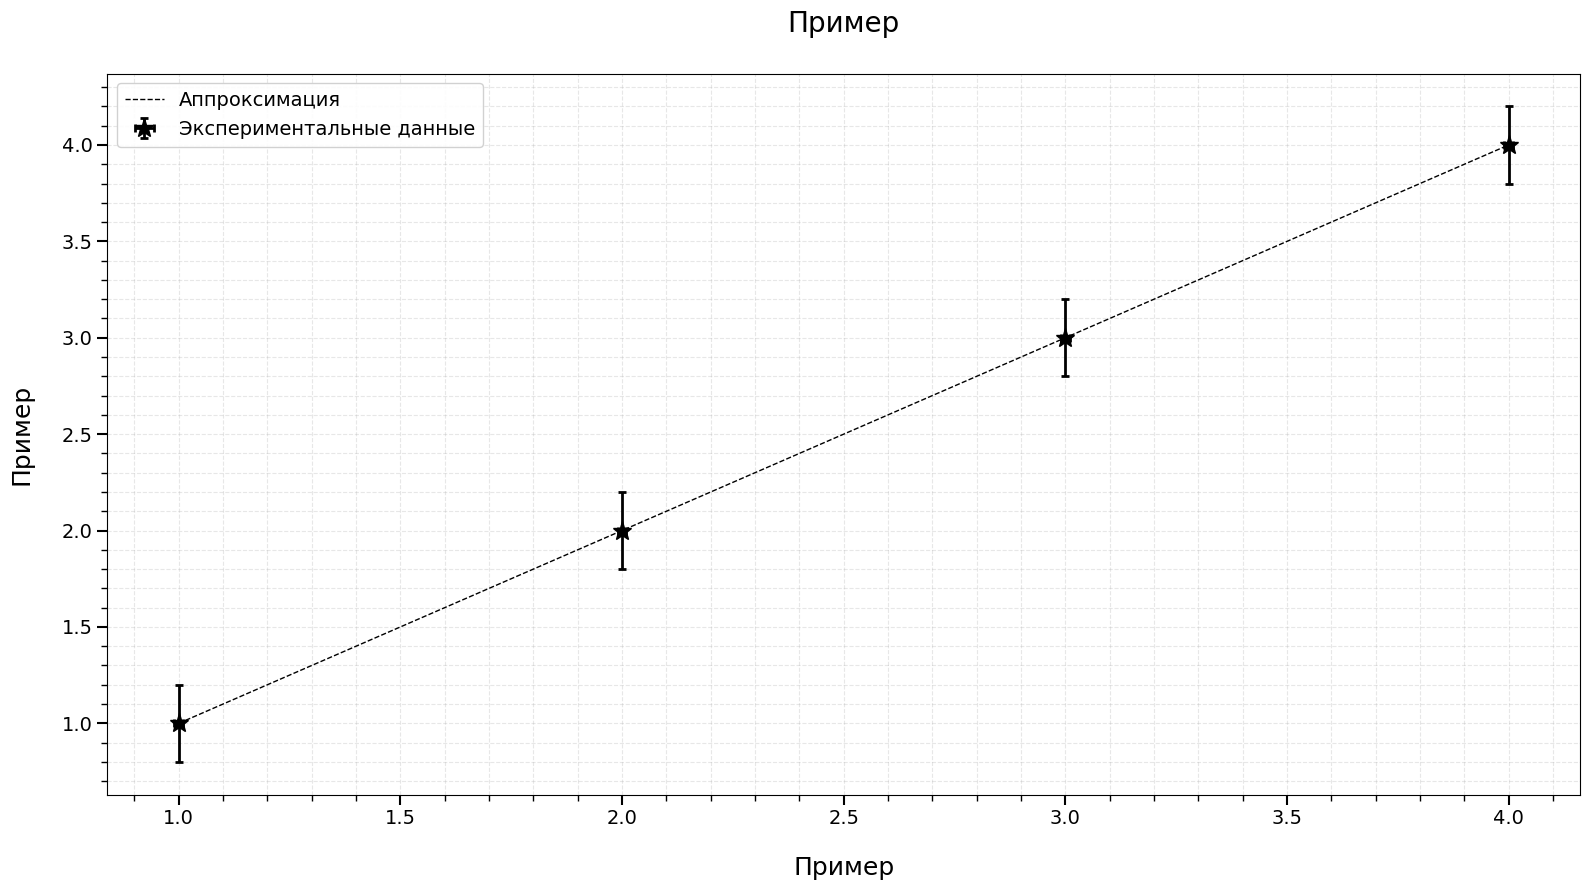

In [ ]:
# --- 2. Построение графика ---
plotter = Plotter(
    title=r'Пример',
    xlabel=r'Пример',
    ylabel=r'Пример'
)

# Добавляем экспериментальные точки
plotter.add_errorbar_points(x, y, xerr=xerr, yerr=yerr, params=plot_args_dict['Error_bars'])

# Добавляем кривую аппроксимации
x_smooth = np.linspace(x.min(), x.max(), 500)
y_fit = func(x_smooth, *popt)

plotter.add_fit_line(x_smooth, y_fit, params=plot_args_dict['Fitted'])

# Финализируем и показываем график
plotter.finalize_and_show("example.pdf")


In [2]:
# 1
R_c = 3.895 #   кОм
E = 10 # В
R_b = 689.7 # кОм
U_c = 4.63 # В
U_BE = 0.66 # В
U_CE = U_c # В

I_b = (E-U_BE)/R_b
I_c = (E-U_CE)/R_c

h_21 = I_c/I_b

print(I_b, I_c, h_21)

0.013542119762215456 1.3786906290115533 101.80759387893664


In [ ]:
import numpy as np
# 2a
R_b = 689.7 # кОм

f_h = 75 # кГц
f_l = 325 # Гц


R_u = 3.92 # кОм

f_m = 5 # кГц
E_u = 37.8 # мВ
U_out = 2.74 # в
U_in = 17.5 # мВ

print(f'U_out/sqrt(2): {U_out/np.sqrt(2)}')

K_u = U_out / U_in * 1e3
K_e = U_out / E_u * 1e3

print(f'K_u: {K_u}, K_e: {K_e}')

R_in = U_in * R_u / (E_u - U_in)

print(f'R_in: {R_in}')

U_out/sqrt(2): 1.9374725804511401
K_u: 156.57142857142858, K_e: 72.48677248677251
R_in: 3.3793103448275863


In [11]:
#2b

R_b = 1345 # кОм

f_h = 93 # кГц
f_l = 530 # Гц

R_u = 3.92 # кОм

f_m = 5 # кГц
E_u = 37.8 # мВ
U_out = 2.62 # в
U_in = 31 # мВ

print(f'U_out/sqrt(2): {U_out/np.sqrt(2)}')

K_u = U_out / U_in * 1e3
K_e = U_out / E_u * 1e3

print(f'K_u: {K_u}, K_e: {K_e}')

R_in = U_in * R_u / (E_u - U_in)

print(f'R_in: {R_in}')


U_out/sqrt(2): 1.8526197667087545
K_u: 84.51612903225806, K_e: 69.31216931216933
R_in: 17.870588235294125


In [12]:
#3

C_p = 166.3 # мкФ

R_b = 689.7 # кОм
R_n = 3.901 # кОм

f_h = 133 # кГц
f_l = 530 # Гц

R_u = 3.92 # кОм

f_m = 5 # кГц
E_u = 37.5 # мВ
U_out = 1.634 # в
U_in = 37.5 # мВ

print(f'U_out/sqrt(2): {U_out/np.sqrt(2)}')

K_u = U_out / U_in * 1e3
K_e = U_out / E_u * 1e3

print(f'K_u: {K_u}, K_e: {K_e}')

R_in = U_in * R_u / (E_u - U_in)

print(f'R_in: {R_in}')


U_out/sqrt(2): 1.1554124804588186
K_u: 43.57333333333333, K_e: 43.57333333333333


ZeroDivisionError: float division by zero

In [ ]:
# 4

R_e = 931.1 # Ом
R_2 = 8.408 # кОм

U_open = 650 # мВ

R_1_approx = (E*R_2/((E*R_e*1e-3)/(2*R_c) + U_open*1e-3)) - R_2

print(f'R_1_approx = {R_1_approx}')

R_1 = 32.55 # кОм
U_c = 5.06 # В
U_b = 1.92 # В
U_e = 1.28 # В

R_1 = 37.157633587255205
